# Intel Image Classification
## 6CS012 – Final Integrated Assessment | Part II: Vision Tasks


## 0. Setup & Imports

In [ ]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/puneet6060
/kaggle/input/datasets/puneet6060/intel-image-classification
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/street
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/buildings
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/sea
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/forest
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/glacier
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_pred
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_pred/seg_pred
/kaggle/input/datasets/puneet6060/in

In [ ]:

import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# ─── Sklearn ─────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# ─── TensorFlow / Keras ───────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2, ResNet50V2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

# ─── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {tf.config.list_physical_devices('GPU')}")

TensorFlow version : 2.19.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:

BASE_DIR  = Path('/kaggle/input/datasets/puneet6060/intel-image-classification')
TRAIN_DIR = BASE_DIR / 'seg_train' / 'seg_train'
TEST_DIR  = BASE_DIR / 'seg_test'  / 'seg_test'
PRED_DIR  = Path('/kaggle/working/seg_pred')

# Create output folder if it doesn't exist
PRED_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
print("Classes detected:", CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)

Classes detected: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of classes: 6


---
# PART A — CNN from Scratch
## 2. Data Understanding, Analysis, Visualization & Cleaning

In [ ]:
# ── 2.1 Count images per split ───────────────────────────────────────────────
def count_images(directory):
    """Return dict {class_name: count} for a directory of class sub-folders."""
    counts = {}
    for cls in sorted(directory.iterdir()):
        if cls.is_dir():
            counts[cls.name] = len(list(cls.glob('*.jpg')) + list(cls.glob('*.png')))
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

total_train = sum(train_counts.values())
total_test  = sum(test_counts.values())

print("=" * 45)
print(f"{'CLASS':<12} {'TRAIN':>8} {'TEST':>8}")
print("-" * 45)
for cls in CLASS_NAMES:
    print(f"{cls:<12} {train_counts.get(cls,0):>8} {test_counts.get(cls,0):>8}")
print("=" * 45)
print(f"{'TOTAL':<12} {total_train:>8} {total_test:>8}")

CLASS           TRAIN     TEST
---------------------------------------------
buildings        2191      437
forest           2271      474
glacier          2404      553
mountain         2512      525
sea              2274      510
street           2382      501
TOTAL           14034     3000


/tmp/ipykernel_57/3744282854.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.keys(), rotation=30, ha='right')
/tmp/ipykernel_57/3744282854.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.keys(), rotation=30, ha='right')


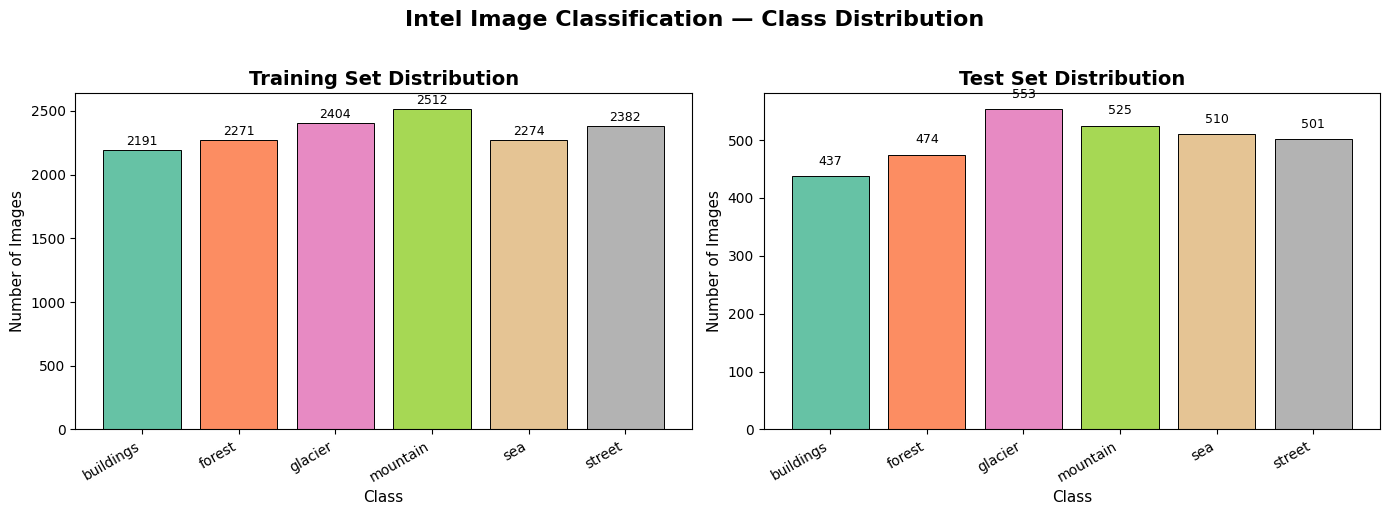


Dataset is roughly balanced.


In [ ]:
# ── 2.2 Class Distribution Bar Chart ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES))

for ax, counts, title in zip(axes,
                              [train_counts, test_counts],
                              ['Training Set Distribution', 'Test Set Distribution']):
    bars = ax.bar(counts.keys(), counts.values(), color=colors, edgecolor='black', linewidth=0.7)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Class', fontsize=11)
    ax.set_ylabel('Number of Images', fontsize=11)
    ax.set_xticklabels(counts.keys(), rotation=30, ha='right')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

plt.suptitle('Intel Image Classification — Class Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nDataset is {'roughly balanced' if max(train_counts.values())/min(train_counts.values()) < 1.5 else 'slightly imbalanced'}.")

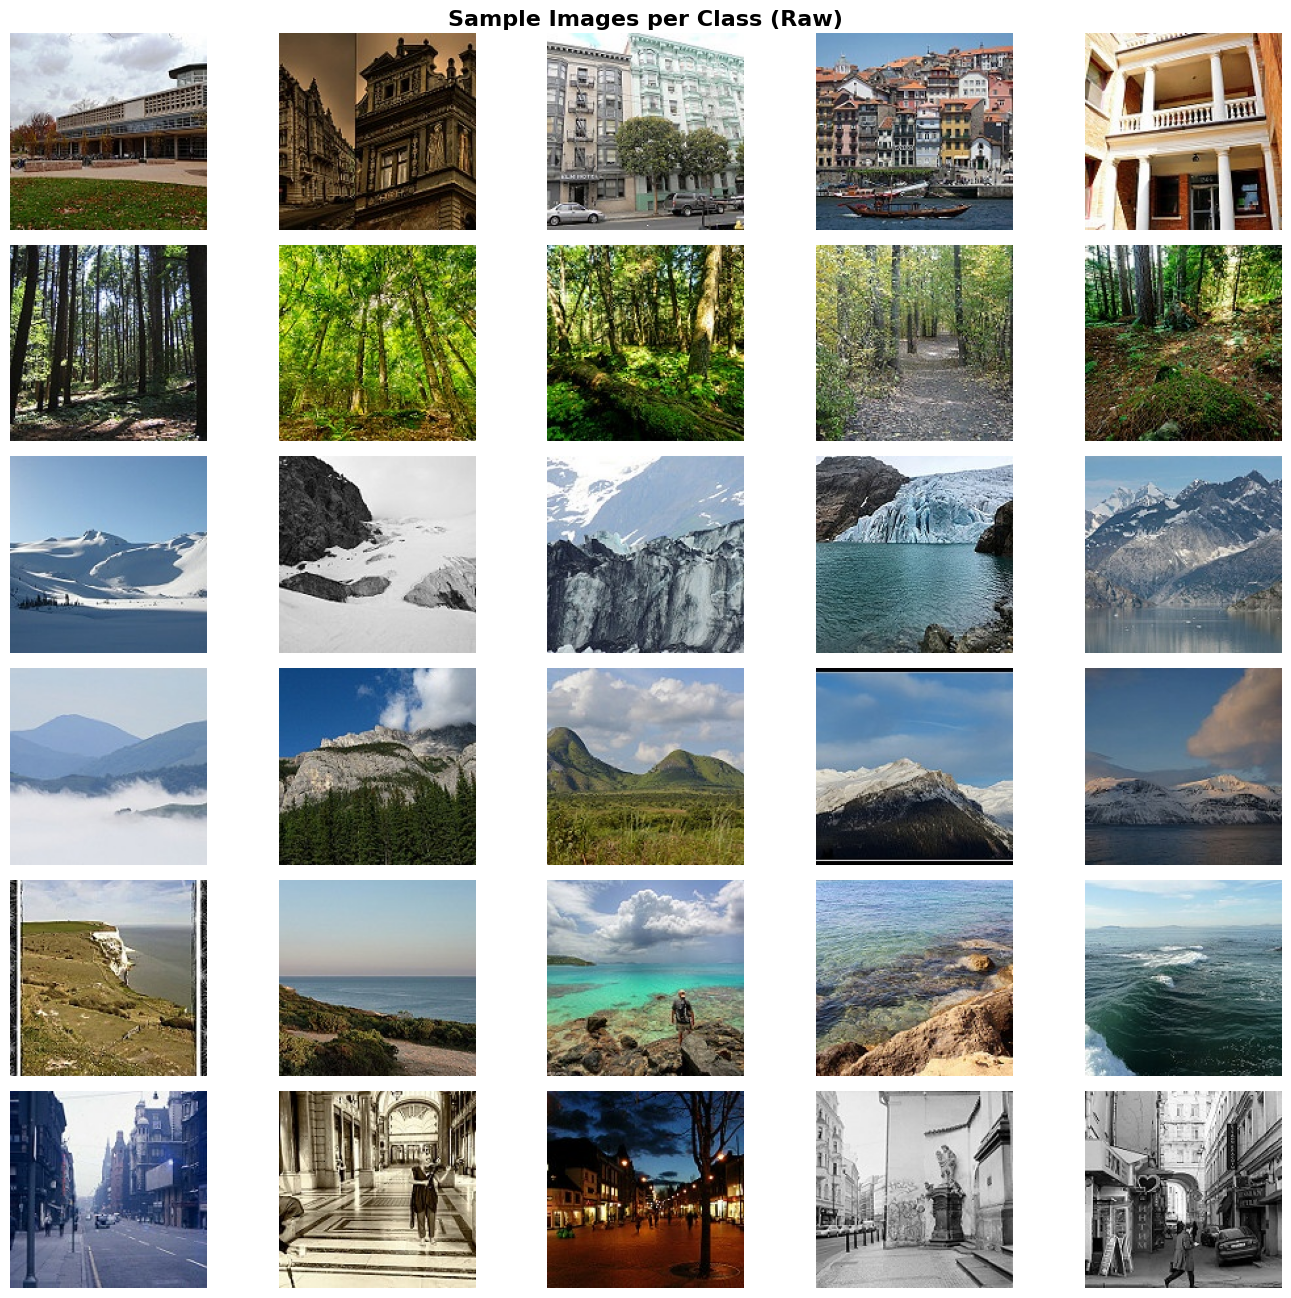

In [ ]:
# ── 2.3 Sample Images per Class ───────────────────────────────────────────────
import cv2
from PIL import Image

fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(14, NUM_CLASSES * 2.2))
fig.suptitle('Sample Images per Class (Raw)', fontsize=16, fontweight='bold')

for row, cls in enumerate(CLASS_NAMES):
    imgs = list((TRAIN_DIR / cls).glob('*.jpg'))[:5]
    for col, img_path in enumerate(imgs):
        img = np.array(Image.open(img_path))
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(cls.capitalize(), fontsize=11, fontweight='bold', rotation=90, labelpad=10)
            axes[row][col].yaxis.label.set_visible(True)

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 2.4 Image Shape Verification ─────────────────────────────────────────────
sample_img = np.array(Image.open(list((TRAIN_DIR / CLASS_NAMES[0]).glob('*.jpg'))[0]))
print(f"Sample image shape : {sample_img.shape}")
print(f"Pixel value range  : [{sample_img.min()}, {sample_img.max()}]")
print(f"\nAll images will be resized to 150x150x3 for training.")

Sample image shape : (150, 150, 3)
Pixel value range  : [0, 255]

All images will be resized to 150x150x3 for training.


## 3. Data Generators — Preprocessing & Augmentation

In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────
IMG_SIZE   = (150, 150)
BATCH_SIZE = 32

# ── Training generator with augmentation ─────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale           = 1./255,       # Normalize [0,1]
    rotation_range    = 20,           # Random rotation ±20°
    width_shift_range = 0.1,          # Horizontal shift
    height_shift_range= 0.1,          # Vertical shift
    shear_range       = 0.1,          # Shear transformation
    zoom_range        = 0.2,          # Random zoom
    horizontal_flip   = True,         # Flip horizontally
    fill_mode         = 'nearest',    # Fill strategy
    validation_split  = 0.2           # 80/20 train-val split
)

# ── Validation/Test generator — NO augmentation ───────────────────────────────
test_datagen = ImageDataGenerator(rescale=1./255)

# ── Flow from directory ───────────────────────────────────────────────────────
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size   = IMG_SIZE,
    batch_size    = BATCH_SIZE,
    class_mode    = 'categorical',
    subset        = 'training',
    seed          = SEED
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size   = IMG_SIZE,
    batch_size    = BATCH_SIZE,
    class_mode    = 'categorical',
    subset        = 'validation',
    seed          = SEED
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size   = IMG_SIZE,
    batch_size    = BATCH_SIZE,
    class_mode    = 'categorical',
    shuffle       = False
)

CLASS_INDICES = train_generator.class_indices
CLASS_LABELS  = {v: k for k, v in CLASS_INDICES.items()}
print("Class indices:", CLASS_INDICES)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Class indices: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


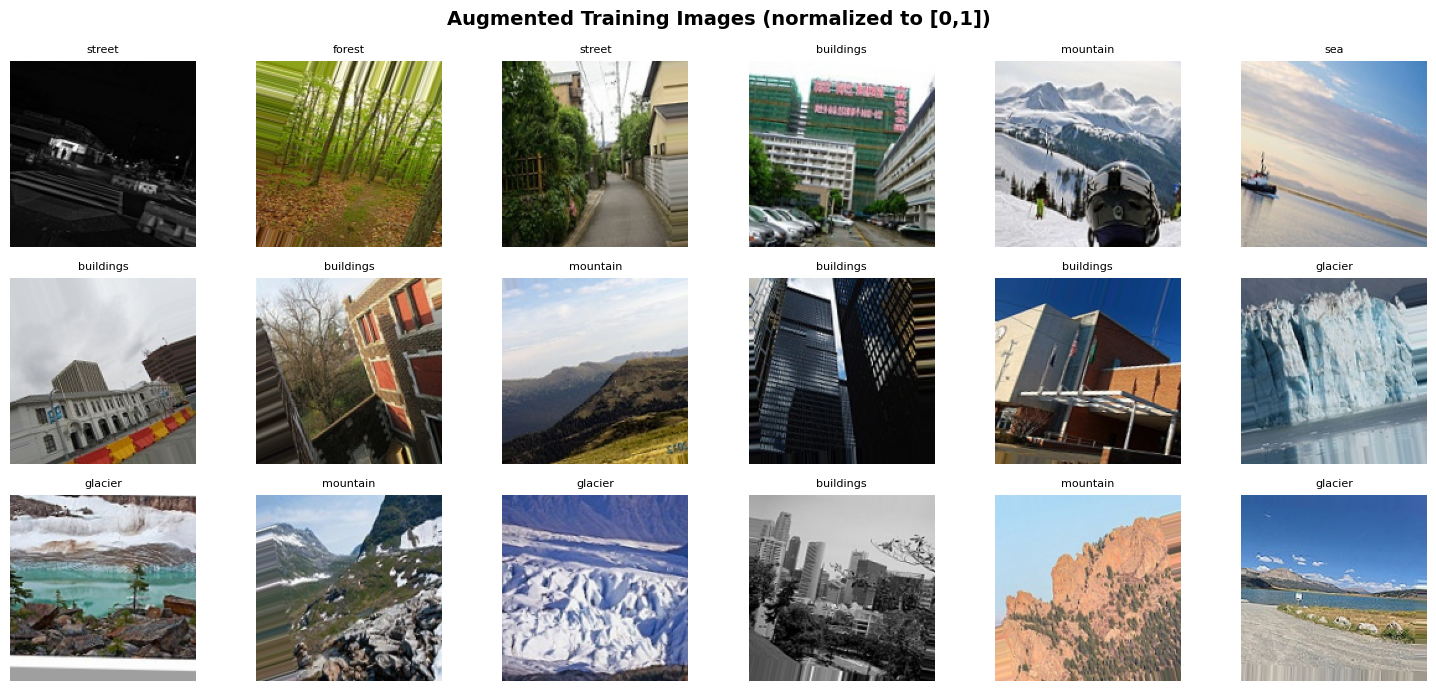

In [ ]:
# ── 3.1 Visualize Augmented Images ────────────────────────────────────────────
sample_imgs, sample_labels = next(train_generator)

fig, axes = plt.subplots(3, 6, figsize=(15, 7))
fig.suptitle('Augmented Training Images (normalized to [0,1])', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(sample_imgs[i])
    ax.set_title(CLASS_LABELS[np.argmax(sample_labels[i])], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Part A — Baseline CNN Model (from Scratch)

In [ ]:
# ── 4.1 Build Baseline CNN ────────────────────────────────────────────────────
# Architecture: 3 Conv+Pool blocks → 3 FC layers → Softmax output

def build_baseline_cnn(num_classes=6, input_shape=(150, 150, 3)):
    model = Sequential([
        # ── Block 1: Conv → ReLU → MaxPool ──────────────────────────────────
        layers.Conv2D(32, kernel_size=(3, 3), activation='relu',
                      padding='same', input_shape=input_shape,
                      name='conv1'),
        layers.MaxPooling2D(pool_size=(2, 2), name='pool1'),

        # ── Block 2: Conv → ReLU → MaxPool ──────────────────────────────────
        layers.Conv2D(64, kernel_size=(3, 3), activation='relu',
                      padding='same', name='conv2'),
        layers.MaxPooling2D(pool_size=(2, 2), name='pool2'),

        # ── Block 3: Conv → ReLU → MaxPool ──────────────────────────────────
        layers.Conv2D(128, kernel_size=(3, 3), activation='relu',
                      padding='same', name='conv3'),
        layers.MaxPooling2D(pool_size=(2, 2), name='pool3'),

        # ── Flatten + FCN layers ─────────────────────────────────────────────
        layers.Flatten(name='flatten'),
        layers.Dense(256, activation='relu', name='fc1'),
        layers.Dense(128, activation='relu', name='fc2'),
        layers.Dense(64,  activation='relu', name='fc3'),

        # ── Output Layer ─────────────────────────────────────────────────────
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='Baseline_CNN')
    return model

baseline_model = build_baseline_cnn(NUM_CLASSES)
baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,751,878 (41.02 MB)

 Trainable params: 10,751,878 (41.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── 4.2 Compile Baseline Model ────────────────────────────────────────────────
baseline_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

# ── Callbacks ─────────────────────────────────────────────────────────────────
callbacks_baseline = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)
]

# ── Train Baseline ────────────────────────────────────────────────────────────
print("Training Baseline CNN...")
t0 = time.time()

history_baseline = baseline_model.fit(
    train_generator,
    epochs          = 30,
    validation_data = val_generator,
    callbacks       = callbacks_baseline,
    verbose         = 1
)

baseline_train_time = time.time() - t0
print(f"\nBaseline training time: {baseline_train_time:.1f} seconds")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Training Baseline CNN...
Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 88s 241ms/step - accuracy: 0.4925 - loss: 1.2339 - val_accuracy: 0.6619 - val_loss: 0.9133 - learning_rate: 0.0010
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 80s 227ms/step - accuracy: 0.6950 - loss: 0.8077 - val_accuracy: 0.7432 - val_loss: 0.6917 - learning_rate: 0.0010
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 80s 229ms/step - accuracy: 0.7480 - loss: 0.6867 - val_accuracy: 0.7778 - val_loss: 0.6254 - learning_rate: 0.0010
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 79s 226ms/step - accuracy: 0.7710 - loss: 0.6181 - val_accuracy: 0.7775 - val_loss: 0.6248 - learning_rate: 0.0010
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 80s 227ms/step - accuracy: 0.7963 - loss: 0.5541 - val_accuracy: 0.7785 - val_loss: 0.5959 - learning_rate: 0.0010
Epoch 6/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 81s 230ms/step - accuracy: 0.8168 - loss: 0.5250 - val_accuracy: 0.8113 - val_loss: 0.5308 - learning_rate: 0.0010
Epoch 7/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 81s 2

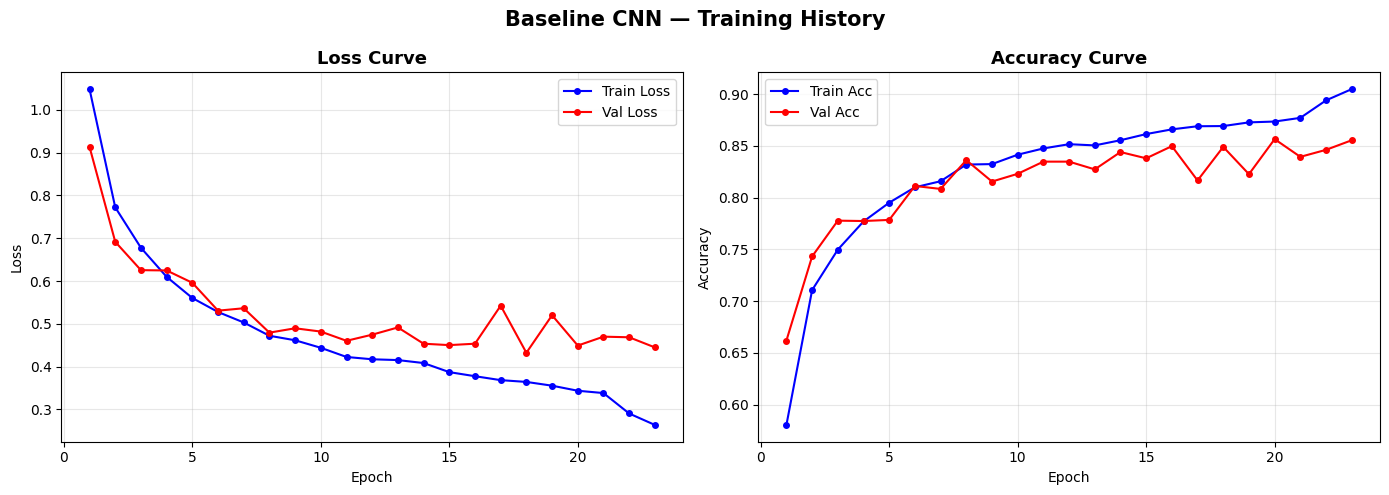

In [ ]:
# ── 4.3 Plot Training Curves ──────────────────────────────────────────────────
def plot_history(history, title='Model Training History', save_name=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history.history['loss']) + 1)

    # Loss
    axes[0].plot(epochs, history.history['loss'],     'b-o', markersize=4, label='Train Loss')
    axes[0].plot(epochs, history.history['val_loss'], 'r-o', markersize=4, label='Val Loss')
    axes[0].set_title('Loss Curve', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, history.history['accuracy'],     'b-o', markersize=4, label='Train Acc')
    axes[1].plot(epochs, history.history['val_accuracy'], 'r-o', markersize=4, label='Val Acc')
    axes[1].set_title('Accuracy Curve', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle(title, fontsize=15, fontweight='bold')
    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history_baseline, 'Baseline CNN — Training History', 'baseline_history.png')


  Baseline CNN — Evaluation Results
  Test Loss     : 0.4284
  Test Accuracy : 0.8570 (85.70%)

Classification Report:
              precision    recall  f1-score   support

   buildings       0.79      0.87      0.83       437
      forest       0.96      0.98      0.97       474
     glacier       0.87      0.77      0.82       553
    mountain       0.77      0.86      0.82       525
         sea       0.92      0.77      0.84       510
      street       0.86      0.90      0.88       501

    accuracy                           0.86      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.86      0.86      3000



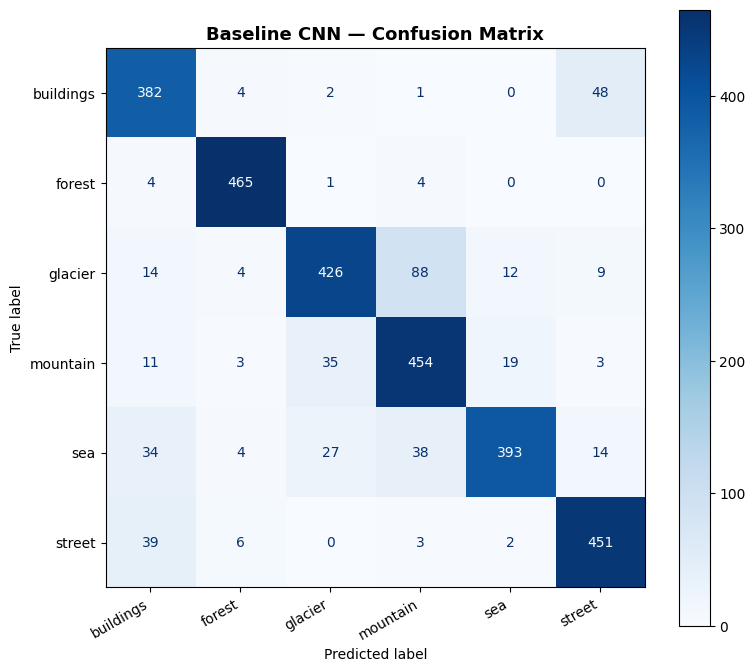

In [ ]:
# ── 4.4 Evaluate Baseline on Test Set ────────────────────────────────────────
def evaluate_model(model, generator, class_labels, model_name='Model'):
    """Full evaluation: loss, accuracy, classification report, confusion matrix."""
    generator.reset()
    test_loss, test_acc = model.evaluate(generator, verbose=0)

    generator.reset()
    y_pred_probs = model.predict(generator, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = generator.classes

    print(f"\n{'='*50}")
    print(f"  {model_name} — Evaluation Results")
    print(f"{'='*50}")
    print(f"  Test Loss     : {test_loss:.4f}")
    print(f"  Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"{'='*50}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=list(class_labels.values())))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 7))
    disp = ConfusionMatrixDisplay(cm, display_labels=list(class_labels.values()))
    disp.plot(ax=ax, colorbar=True, cmap='Blues')
    ax.set_title(f'{model_name} — Confusion Matrix', fontsize=13, fontweight='bold')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ","_")}_cm.png', dpi=150, bbox_inches='tight')
    plt.show()

    return test_loss, test_acc, y_pred, y_true

b_loss, b_acc, b_pred, b_true = evaluate_model(
    baseline_model, test_generator, CLASS_LABELS, 'Baseline CNN'
)

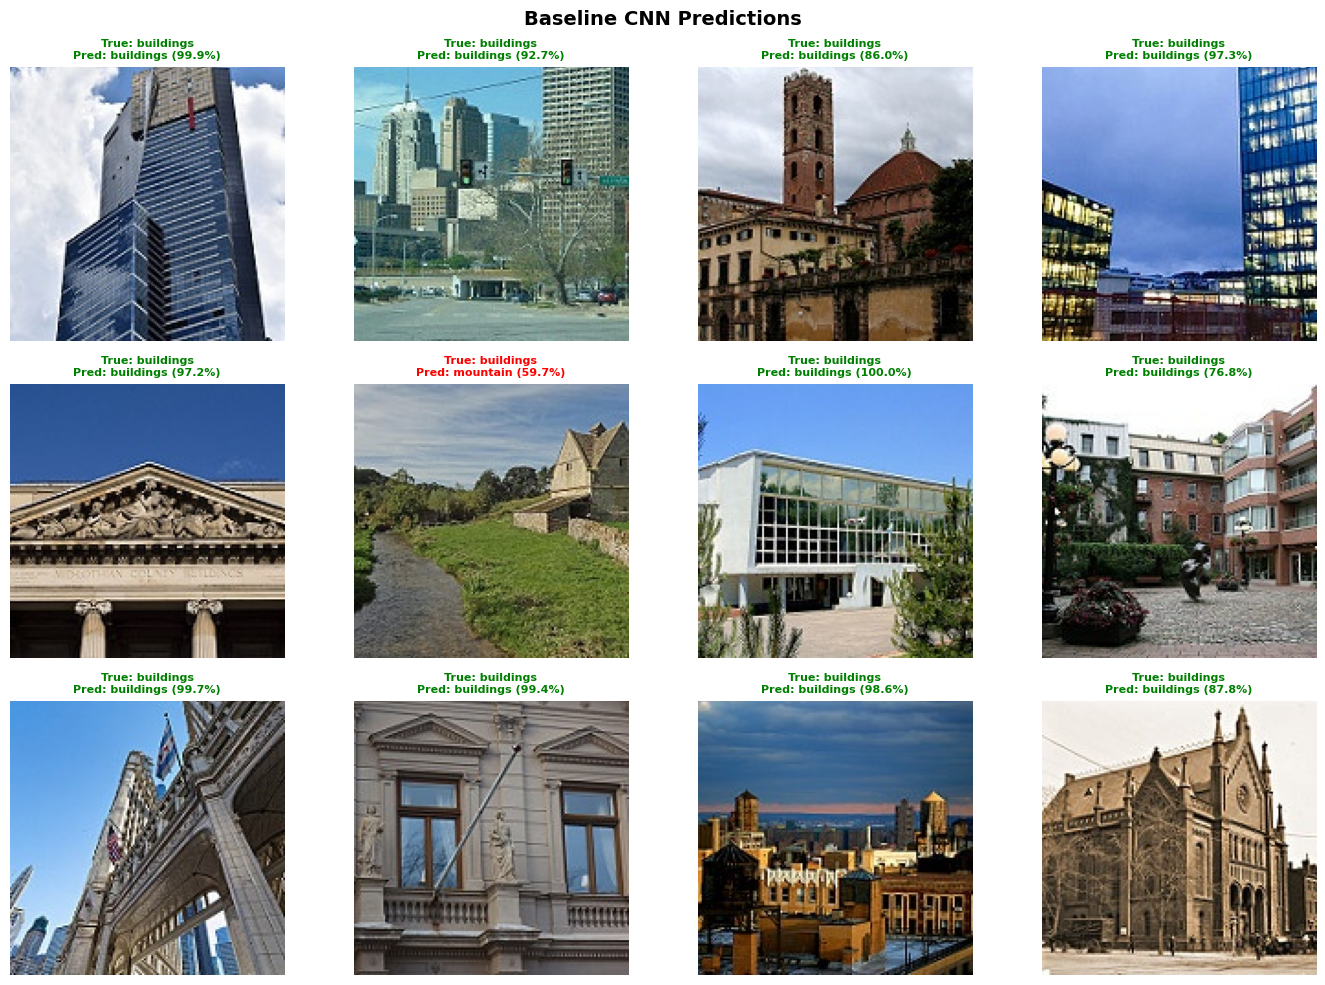

In [ ]:
# ── 4.5 Sample Inference Visualization ───────────────────────────────────────
def visualize_predictions(model, generator, class_labels, n=12, title='Predictions'):
    generator.reset()
    imgs, labels = next(generator)
    preds = model.predict(imgs, verbose=0)

    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for i, ax in enumerate(axes.flat):
        if i >= n: break
        ax.imshow(imgs[i])
        true_label = class_labels[np.argmax(labels[i])]
        pred_label = class_labels[np.argmax(preds[i])]
        confidence = np.max(preds[i]) * 100
        color = 'green' if true_label == pred_label else 'red'
        ax.set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)',
                     fontsize=8, color=color, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_predictions(baseline_model, test_generator, CLASS_LABELS, title='Baseline CNN Predictions')

## 5. Part A — Deeper CNN with Regularization

In [ ]:
# ── 5.1 Build Deeper CNN ──────────────────────────────────────────────────────
# Architecture: 6 Conv+Pool blocks with BatchNorm & Dropout → 3 FC layers → Softmax

def build_deeper_cnn(num_classes=6, input_shape=(150, 150, 3)):
    model = Sequential([
        # ── Block 1 ─────────────────────────────────────────────────────────
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape, name='conv1_1'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same', name='conv1_2'),
        layers.BatchNormalization(name='bn1'),
        layers.MaxPooling2D((2,2), name='pool1'),
        layers.Dropout(0.25, name='drop1'),

        # ── Block 2 ─────────────────────────────────────────────────────────
        layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2_1'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2_2'),
        layers.BatchNormalization(name='bn2'),
        layers.MaxPooling2D((2,2), name='pool2'),
        layers.Dropout(0.25, name='drop2'),

        # ── Block 3 ─────────────────────────────────────────────────────────
        layers.Conv2D(128, (3,3), activation='relu', padding='same', name='conv3_1'),
        layers.Conv2D(128, (3,3), activation='relu', padding='same', name='conv3_2'),
        layers.BatchNormalization(name='bn3'),
        layers.MaxPooling2D((2,2), name='pool3'),
        layers.Dropout(0.3, name='drop3'),

        # ── Block 4 ─────────────────────────────────────────────────────────
        layers.Conv2D(256, (3,3), activation='relu', padding='same', name='conv4_1'),
        layers.Conv2D(256, (3,3), activation='relu', padding='same', name='conv4_2'),
        layers.BatchNormalization(name='bn4'),
        layers.MaxPooling2D((2,2), name='pool4'),
        layers.Dropout(0.3, name='drop4'),

        # ── Flatten + FCN layers ─────────────────────────────────────────────
        layers.GlobalAveragePooling2D(name='gap'),
        layers.Dense(512, activation='relu', name='fc1'),
        layers.BatchNormalization(name='bn_fc1'),
        layers.Dropout(0.5, name='drop_fc1'),
        layers.Dense(256, activation='relu', name='fc2'),
        layers.Dropout(0.4, name='drop_fc2'),
        layers.Dense(128, activation='relu', name='fc3'),

        # ── Output ───────────────────────────────────────────────────────────
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='Deeper_CNN')
    return model

deeper_model = build_deeper_cnn(NUM_CLASSES)
deeper_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 150, 150, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 75, 75, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 37, 37, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_1 (Conv2D)                │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_2 (Conv2D)                │ (None, 18, 18, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 18, 18, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop4 (Dropout)                 │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_fc1 (BatchNormalization)     │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_fc1 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 256)            │       131,32

 Total params: 1,472,806 (5.62 MB)

 Trainable params: 1,470,822 (5.61 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
# ── 5.2 Compile & Train Deeper CNN (Adam) ────────────────────────────────────
deeper_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

callbacks_deeper = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-7),
    ModelCheckpoint('deeper_best.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print("Training Deeper CNN (Adam)...")
t1 = time.time()

history_deeper = deeper_model.fit(
    train_generator,
    epochs          = 40,
    validation_data = val_generator,
    callbacks       = callbacks_deeper,
    verbose         = 1
)

deeper_train_time_adam = time.time() - t1
print(f"\nDeeper CNN (Adam) training time: {deeper_train_time_adam:.1f} seconds")

Training Deeper CNN (Adam)...
Epoch 1/40


2026-05-07 07:58:22.788832: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 07:58:22.948315: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 07:58:24.740362: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 07:58:25.032226: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


196/351 ━━━━━━━━━━━━━━━━━━━━ 30s 194ms/step - accuracy: 0.3777 - loss: 1.6396

2026-05-07 07:59:15.977208: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 07:59:16.132964: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 07:59:17.596266: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 07:59:17.883102: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


351/351 ━━━━━━━━━━━━━━━━━━━━ 125s 296ms/step - accuracy: 0.4157 - loss: 1.5176 - val_accuracy: 0.3588 - val_loss: 1.9736 - learning_rate: 0.0010
Epoch 2/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 85s 241ms/step - accuracy: 0.5868 - loss: 1.0357 - val_accuracy: 0.5471 - val_loss: 1.3133 - learning_rate: 0.0010
Epoch 3/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 98s 278ms/step - accuracy: 0.6769 - loss: 0.8556 - val_accuracy: 0.6701 - val_loss: 0.9084 - learning_rate: 0.0010
Epoch 4/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 84s 240ms/step - accuracy: 0.7388 - loss: 0.7362 - val_accuracy: 0.6694 - val_loss: 0.9849 - learning_rate: 0.0010
Epoch 5/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 85s 242ms/step - accuracy: 0.7505 - loss: 0.6816 - val_accuracy: 0.7068 - val_loss: 0.7685 - learning_rate: 0.0010
Epoch 6/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 86s 246ms/step - accuracy: 0.7759 - loss: 0.6297 - val_accuracy: 0.6744 - val_loss: 1.0845 - learning_rate: 0.0010
Epoch 7/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 85s 242ms/step - accuracy: 0.7934 - loss

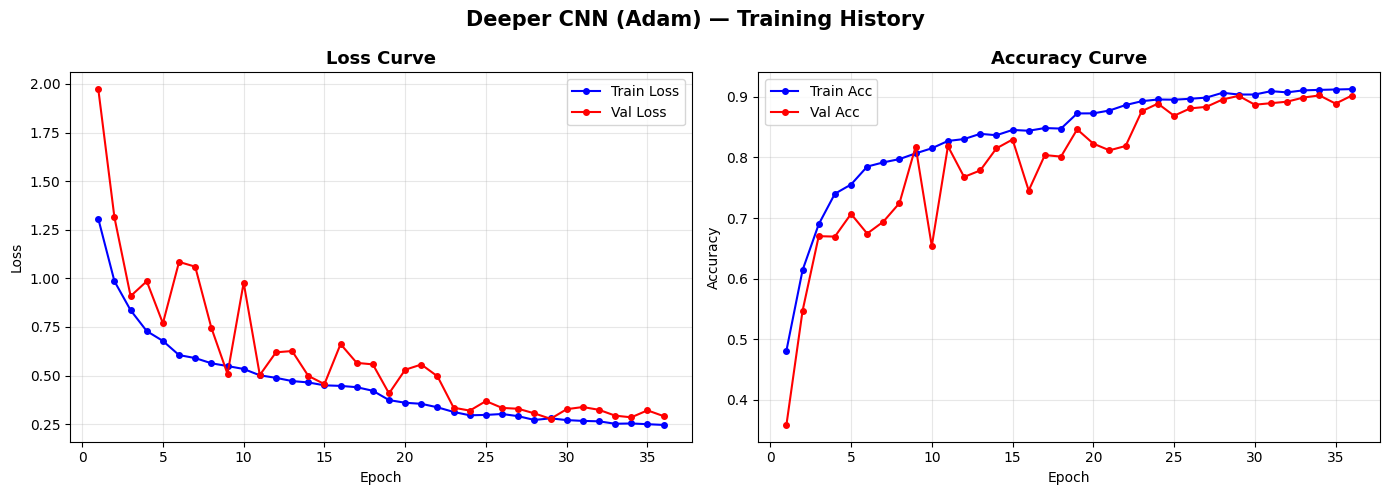


  Deeper CNN (Adam) — Evaluation Results
  Test Loss     : 0.3524
  Test Accuracy : 0.8813 (88.13%)

Classification Report:
              precision    recall  f1-score   support

   buildings       0.81      0.94      0.87       437
      forest       0.97      0.97      0.97       474
     glacier       0.88      0.82      0.85       553
    mountain       0.85      0.81      0.83       525
         sea       0.85      0.94      0.90       510
      street       0.95      0.83      0.89       501

    accuracy                           0.88      3000
   macro avg       0.88      0.88      0.88      3000
weighted avg       0.88      0.88      0.88      3000



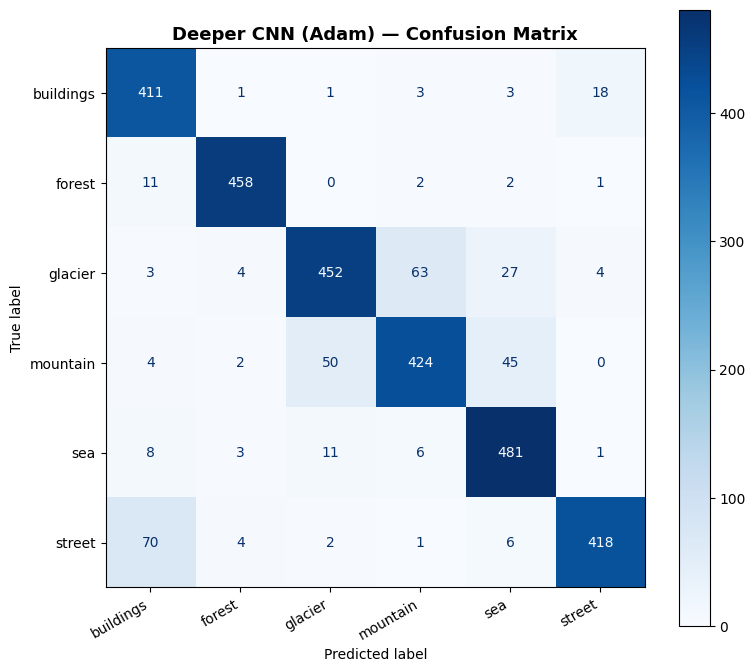

In [ ]:
# ── 5.3 Plot Deeper Model History ────────────────────────────────────────────
plot_history(history_deeper, 'Deeper CNN (Adam) — Training History', 'deeper_adam_history.png')

# ── 5.4 Evaluate Deeper Model (Adam) ─────────────────────────────────────────
d_loss, d_acc, d_pred, d_true = evaluate_model(
    deeper_model, test_generator, CLASS_LABELS, 'Deeper CNN (Adam)'
)

## 6. Experimentation & Comparative Analysis
### 6.1 Optimizer Comparison: SGD vs Adam

In [ ]:
# ── 6.1 Train Deeper CNN with SGD ────────────────────────────────────────────
deeper_model_sgd = build_deeper_cnn(NUM_CLASSES)
deeper_model_sgd.compile(
    optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

callbacks_sgd = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-7)
]

print("Training Deeper CNN (SGD)...")
t2 = time.time()

history_deeper_sgd = deeper_model_sgd.fit(
    train_generator,
    epochs          = 40,
    validation_data = val_generator,
    callbacks       = callbacks_sgd,
    verbose         = 1
)

deeper_train_time_sgd = time.time() - t2
print(f"\nDeeper CNN (SGD) training time: {deeper_train_time_sgd:.1f} seconds")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Deeper CNN (SGD)...
Epoch 1/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 106s 273ms/step - accuracy: 0.3772 - loss: 1.5809 - val_accuracy: 0.2126 - val_loss: 2.1449 - learning_rate: 0.0100
Epoch 2/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 87s 247ms/step - accuracy: 0.5519 - loss: 1.1103 - val_accuracy: 0.3563 - val_loss: 1.7639 - learning_rate: 0.0100
Epoch 3/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 85s 241ms/step - accuracy: 0.6168 - loss: 0.9974 - val_accuracy: 0.5392 - val_loss: 1.3390 - learning_rate: 0.0100
Epoch 4/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 86s 244ms/step - accuracy: 0.6707 - loss: 0.8891 - val_accuracy: 0.4536 - val_loss: 1.5619 - learning_rate: 0.0100
Epoch 5/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 86s 245ms/step - accuracy: 0.6975 - loss: 0.8140 - val_accuracy: 0.6034 - val_loss: 1.1380 - learning_rate: 0.0100
Epoch 6/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 84s 239ms/step - accuracy: 0.7279 - loss: 0.7401 - val_accuracy: 0.6623 - val_loss: 0.9461 - learning_rate: 0.0100
Epoch 7/40
351/351 ━━━━━━━━━━━━━━━━━━━━ 

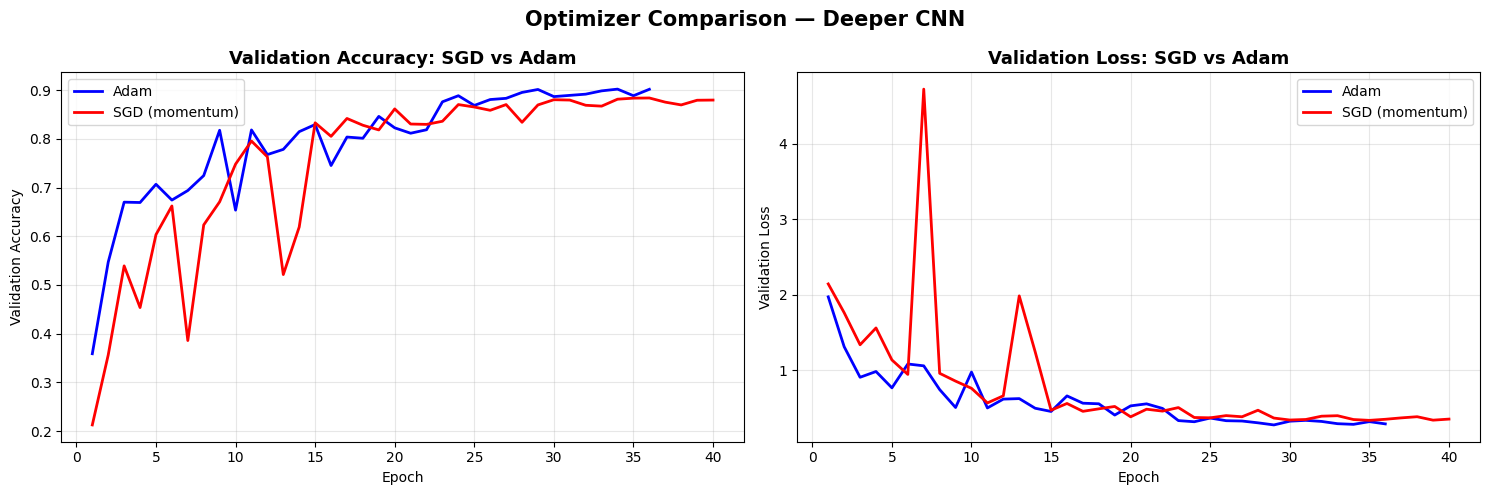


  Deeper CNN (SGD) — Evaluation Results
  Test Loss     : 0.3736
  Test Accuracy : 0.8763 (87.63%)

Classification Report:
              precision    recall  f1-score   support

   buildings       0.91      0.86      0.88       437
      forest       0.88      0.99      0.93       474
     glacier       0.85      0.84      0.84       553
    mountain       0.87      0.79      0.83       525
         sea       0.85      0.94      0.89       510
      street       0.91      0.85      0.88       501

    accuracy                           0.88      3000
   macro avg       0.88      0.88      0.88      3000
weighted avg       0.88      0.88      0.88      3000



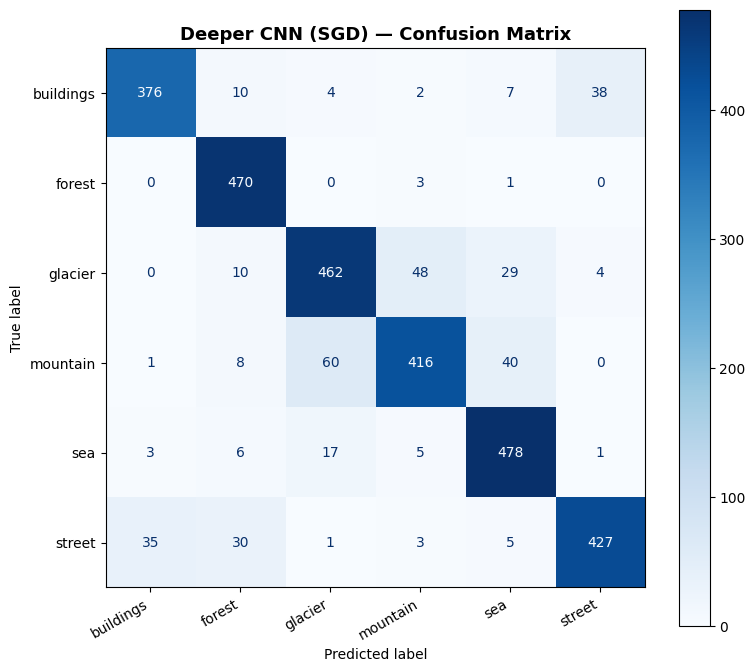

In [ ]:
# ── 6.2 SGD vs Adam Comparison Plot ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Validation Accuracy
e_adam = range(1, len(history_deeper.history['val_accuracy']) + 1)
e_sgd  = range(1, len(history_deeper_sgd.history['val_accuracy']) + 1)

axes[0].plot(e_adam, history_deeper.history['val_accuracy'],     'b-', linewidth=2, label='Adam')
axes[0].plot(e_sgd,  history_deeper_sgd.history['val_accuracy'], 'r-', linewidth=2, label='SGD (momentum)')
axes[0].set_title('Validation Accuracy: SGD vs Adam', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Validation Loss
axes[1].plot(e_adam, history_deeper.history['val_loss'],     'b-', linewidth=2, label='Adam')
axes[1].plot(e_sgd,  history_deeper_sgd.history['val_loss'], 'r-', linewidth=2, label='SGD (momentum)')
axes[1].set_title('Validation Loss: SGD vs Adam', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Optimizer Comparison — Deeper CNN', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

sgd_loss, sgd_acc, _, _ = evaluate_model(
    deeper_model_sgd, test_generator, CLASS_LABELS, 'Deeper CNN (SGD)'
)

### 6.2 Ablation Study — Effect of Dropout

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Ablation Model (No Dropout)...
Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 103s 260ms/step - accuracy: 0.5167 - loss: 1.2442 - val_accuracy: 0.3677 - val_loss: 2.2536 - learning_rate: 0.0010
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 83s 237ms/step - accuracy: 0.6627 - loss: 0.8724 - val_accuracy: 0.5856 - val_loss: 1.0860 - learning_rate: 0.0010
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 85s 242ms/step - accuracy: 0.7360 - loss: 0.7230 - val_accuracy: 0.7272 - val_loss: 0.7838 - learning_rate: 0.0010
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 84s 240ms/step - accuracy: 0.7631 - loss: 0.6461 - val_accuracy: 0.4950 - val_loss: 1.5271 - learning_rate: 0.0010
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 90s 256ms/step - accuracy: 0.7844 - loss: 0.5982 - val_accuracy: 0.5439 - val_loss: 1.2285 - learning_rate: 0.0010
Epoch 6/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 83s 237ms/step - accuracy: 0.7974 - loss: 0.5745 - val_accuracy: 0.7825 - val_loss: 0.6329 - learning_rate: 0.0010
Epoch 7/30
351/351 ━━━━━━━━━━

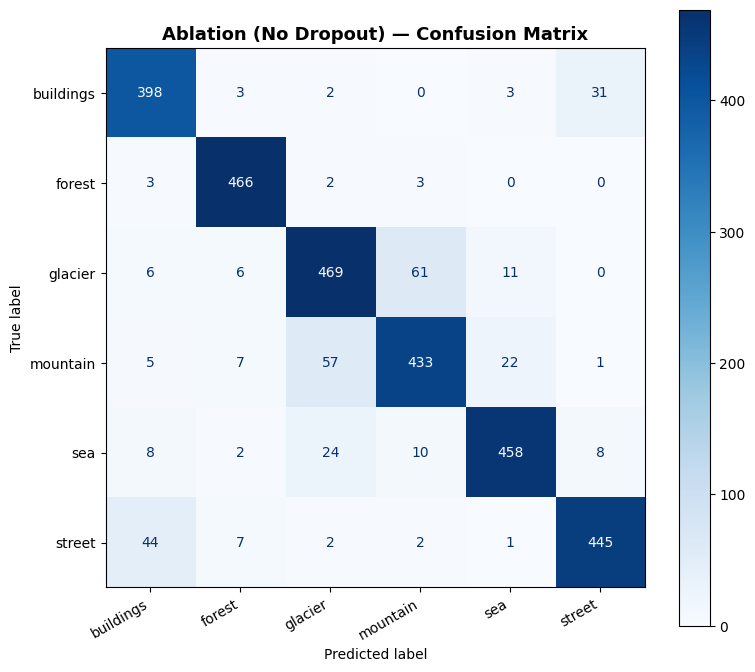

In [ ]:
# ── 6.3 Ablation: Deeper CNN WITHOUT Dropout ─────────────────────────────────
def build_deeper_cnn_no_dropout(num_classes=6, input_shape=(150, 150, 3)):
    """Same as deeper CNN but with all Dropout layers removed."""
    model = Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='Deeper_CNN_No_Dropout')
    return model

ablation_model = build_deeper_cnn_no_dropout(NUM_CLASSES)
ablation_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

callbacks_ablation = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print("Training Ablation Model (No Dropout)...")
history_ablation = ablation_model.fit(
    train_generator,
    epochs          = 30,
    validation_data = val_generator,
    callbacks       = callbacks_ablation,
    verbose         = 1
)

abl_loss, abl_acc, _, _ = evaluate_model(
    ablation_model, test_generator, CLASS_LABELS, 'Ablation (No Dropout)'
)

### 6.3 Baseline vs Deeper — Side-by-Side Comparison

In [ ]:
# ── 6.4 Summary Comparison Table ─────────────────────────────────────────────
results = {
    'Model'            : ['Baseline CNN', 'Deeper CNN (Adam)', 'Deeper CNN (SGD)', 'Ablation (No Dropout)'],
    'Test Accuracy (%)': [b_acc*100, d_acc*100, sgd_acc*100, abl_acc*100],
    'Test Loss'        : [b_loss, d_loss, sgd_loss, abl_loss],
    'Train Time (s)'   : [baseline_train_time, deeper_train_time_adam, deeper_train_time_sgd, 'N/A']
}

print("\n" + "="*70)
print(f"{'Model':<28} {'Test Acc (%)':>14} {'Test Loss':>12} {'Train Time':>12}")
print("-"*70)
for i in range(len(results['Model'])):
    print(f"{results['Model'][i]:<28} "
          f"{results['Test Accuracy (%)'][i]:>14.2f} "
          f"{results['Test Loss'][i]:>12.4f} "
          f"{str(results['Train Time (s)'][i]):>12}")
print("="*70)


Model                          Test Acc (%)    Test Loss   Train Time
----------------------------------------------------------------------
Baseline CNN                          85.70       0.4284 1858.4343707561493
Deeper CNN (Adam)                     88.13       0.3524 3143.1426310539246
Deeper CNN (SGD)                      87.63       0.3736 3445.4874176979065
Ablation (No Dropout)                 88.97       0.3069          N/A


/tmp/ipykernel_57/2918565740.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=10)


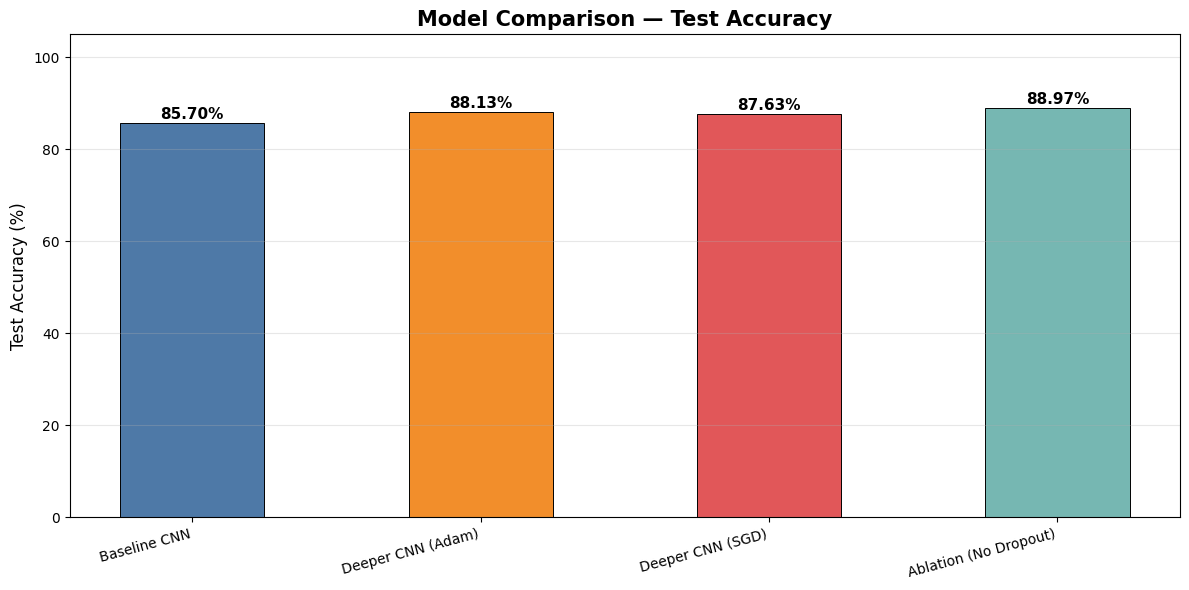

In [ ]:
# ── 6.5 Visual Comparison Bar Chart ──────────────────────────────────────────
model_names  = results['Model']
accuracies   = results['Test Accuracy (%)']
colors_comp  = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(model_names, accuracies, color=colors_comp, edgecolor='black', linewidth=0.7, width=0.5)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Model Comparison — Test Accuracy', fontsize=15, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_ylim(0, 105)
ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

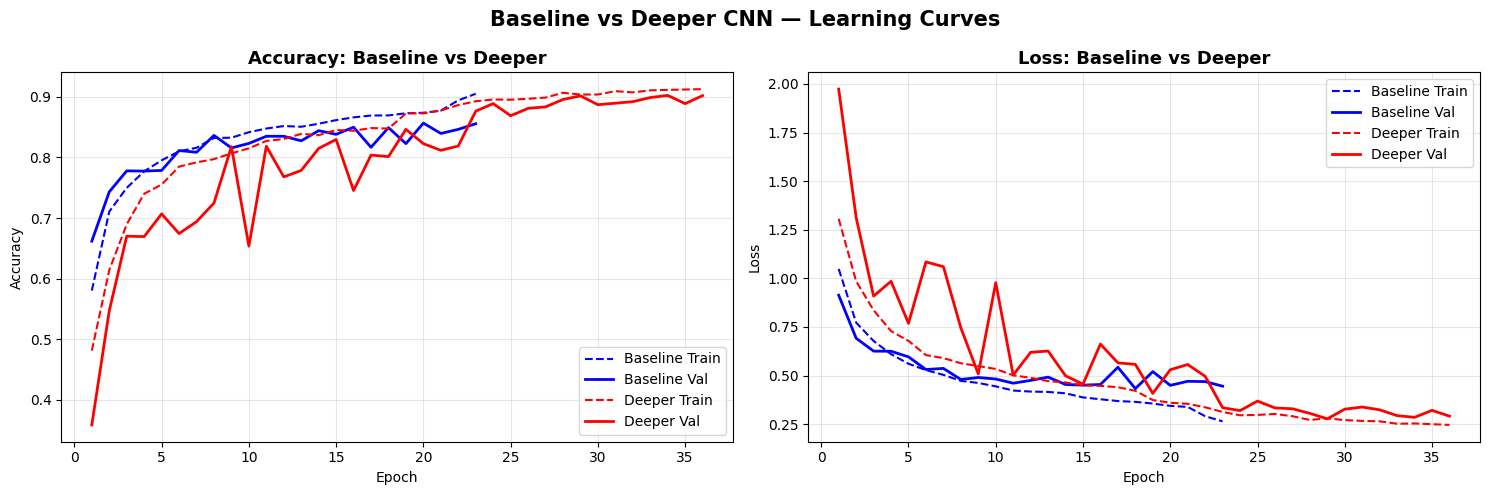

In [ ]:
# ── 6.6 Baseline vs Deeper — Combined Learning Curves ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

e_b = range(1, len(history_baseline.history['val_accuracy']) + 1)
e_d = range(1, len(history_deeper.history['val_accuracy']) + 1)

axes[0].plot(e_b, history_baseline.history['accuracy'],     'b--', label='Baseline Train')
axes[0].plot(e_b, history_baseline.history['val_accuracy'], 'b-',  label='Baseline Val', linewidth=2)
axes[0].plot(e_d, history_deeper.history['accuracy'],       'r--', label='Deeper Train')
axes[0].plot(e_d, history_deeper.history['val_accuracy'],   'r-',  label='Deeper Val', linewidth=2)
axes[0].set_title('Accuracy: Baseline vs Deeper', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(e_b, history_baseline.history['loss'],     'b--', label='Baseline Train')
axes[1].plot(e_b, history_baseline.history['val_loss'], 'b-',  label='Baseline Val', linewidth=2)
axes[1].plot(e_d, history_deeper.history['loss'],       'r--', label='Deeper Train')
axes[1].plot(e_d, history_deeper.history['val_loss'],   'r-',  label='Deeper Val', linewidth=2)
axes[1].set_title('Loss: Baseline vs Deeper', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Baseline vs Deeper CNN — Learning Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_vs_deeper_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PART B — Transfer Learning (MobileNetV2)
## 7. Loading and Adapting a Pre-Trained Model

In [ ]:
from pathlib import Path

BASE_DIR  = Path('/kaggle/input/datasets/puneet6060/intel-image-classification')
TRAIN_DIR = BASE_DIR / 'seg_train' / 'seg_train'
TEST_DIR  = BASE_DIR / 'seg_test'  / 'seg_test'
PRED_DIR  = Path('/kaggle/working/seg_pred')
PRED_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 32
IMG_SIZE = (150, 150)
NUM_CLASSES = 6
CLASS_NAMES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
CLASS_LABELS = CLASS_NAMES
SEED = 42

print("TRAIN_DIR:", TRAIN_DIR)
print("Classes:", CLASS_NAMES)

TRAIN_DIR: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [ ]:
# ── 7.1 Data generators for Transfer Learning (224x224 for MobileNetV2) ──────
TL_IMG_SIZE = (224, 224)

tl_train_datagen = ImageDataGenerator(
    preprocessing_function = mobilenet_preprocess,
    rotation_range         = 20,
    width_shift_range      = 0.1,
    height_shift_range     = 0.1,
    zoom_range             = 0.2,
    horizontal_flip        = True,
    validation_split       = 0.2
)

tl_test_datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess)

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=SEED
)
tl_val_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=SEED
)
tl_test_gen = tl_test_datagen.flow_from_directory(
    TEST_DIR, target_size=TL_IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

print("Transfer learning generators ready.")

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Transfer learning generators ready.


In [ ]:
# ── 7.2 Build Transfer Learning Model (Feature Extraction Phase) ──────────────
# Load MobileNetV2 pretrained on ImageNet, exclude top layers
base_model = MobileNetV2(
    weights      = 'imagenet',
    include_top  = False,
    input_shape  = (224, 224, 3)
)

# Freeze convolutional base (feature extraction)
base_model.trainable = False
print(f"MobileNetV2 base: {len(base_model.layers)} layers, all frozen.")

# Add custom classification head
inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = Model(inputs, outputs, name='MobileNetV2_Transfer')
tl_model.summary()

MobileNetV2 base: 154 layers, all frozen.


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,614 (10.00 MB)

 Trainable params: 362,118 (1.38 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [ ]:
# ── 7.3 Phase 1: Feature Extraction (Frozen Base) ────────────────────────────
tl_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

callbacks_tl = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-7),
    ModelCheckpoint('tl_best_phase1.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print("Phase 1: Training classification head (frozen base)...")
t3 = time.time()

history_tl_phase1 = tl_model.fit(
    tl_train_gen,
    epochs          = 20,
    validation_data = tl_val_gen,
    callbacks       = callbacks_tl,
    verbose         = 1
)

tl_phase1_time = time.time() - t3
print(f"\nPhase 1 training time: {tl_phase1_time:.1f} seconds")

Phase 1: Training classification head (frozen base)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 175s 470ms/step - accuracy: 0.7409 - loss: 0.7563 - val_accuracy: 0.8820 - val_loss: 0.3112 - learning_rate: 0.0010
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 155s 443ms/step - accuracy: 0.8518 - loss: 0.3976 - val_accuracy: 0.8994 - val_loss: 0.2786 - learning_rate: 0.0010
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 153s 436ms/step - accuracy: 0.8780 - loss: 0.3431 - val_accuracy: 0.8944 - val_loss: 0.2753 - learning_rate: 0.0010
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 158s 449ms/step - accuracy: 0.8771 - loss: 0.3348 - val_accuracy: 0.8909 - val_loss: 0.2864 - learning_rate: 0.0010
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 154s 439ms/step - accuracy: 0.8900 - loss: 0.3024 - val_accuracy: 0.8994 - val_loss: 0.2665 - learning_rate: 0.0010
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 154s 440ms/step - accuracy: 0.8914 - loss: 0.2964 - val_accuracy: 0.8994 - val_loss: 0.2751 - learning_rate: 0.0010
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 152s 434ms/step - accura

In [ ]:
# ── 7.4 Phase 2: Fine-Tuning (Unfreeze top layers) ───────────────────────────
# Unfreeze the last 30 layers of MobileNetV2 base
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in tl_model.layers if l.trainable)
print(f"Trainable layers after unfreezing: {trainable_count}")

# Recompile with lower learning rate to avoid catastrophic forgetting
tl_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-5),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

callbacks_tl_ft = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-8),
    ModelCheckpoint('tl_best_phase2.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print("\nPhase 2: Fine-tuning (last 30 layers unfrozen)...")
t4 = time.time()

history_tl_phase2 = tl_model.fit(
    tl_train_gen,
    epochs          = 20,
    validation_data = tl_val_gen,
    callbacks       = callbacks_tl_ft,
    verbose         = 1
)

tl_phase2_time = time.time() - t4
tl_total_time  = tl_phase1_time + tl_phase2_time
print(f"\nPhase 2 training time: {tl_phase2_time:.1f} seconds")
print(f"Total TL training time: {tl_total_time:.1f} seconds")

Trainable layers after unfreezing: 9

Phase 2: Fine-tuning (last 30 layers unfrozen)...
Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 186s 485ms/step - accuracy: 0.8501 - loss: 0.4401 - val_accuracy: 0.8852 - val_loss: 0.3184 - learning_rate: 1.0000e-05
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 156s 443ms/step - accuracy: 0.8735 - loss: 0.3403 - val_accuracy: 0.9012 - val_loss: 0.2862 - learning_rate: 1.0000e-05
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 159s 453ms/step - accuracy: 0.8925 - loss: 0.3046 - val_accuracy: 0.9044 - val_loss: 0.2742 - learning_rate: 1.0000e-05
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 156s 445ms/step - accuracy: 0.8946 - loss: 0.2863 - val_accuracy: 0.9037 - val_loss: 0.2658 - learning_rate: 1.0000e-05
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 155s 441ms/step - accuracy: 0.8994 - loss: 0.2795 - val_accuracy: 0.9105 - val_loss: 0.2542 - learning_rate: 1.0000e-05
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 156s 444ms/step - accuracy: 0.9051 - loss: 0.2708 - val_accuracy: 0.9069

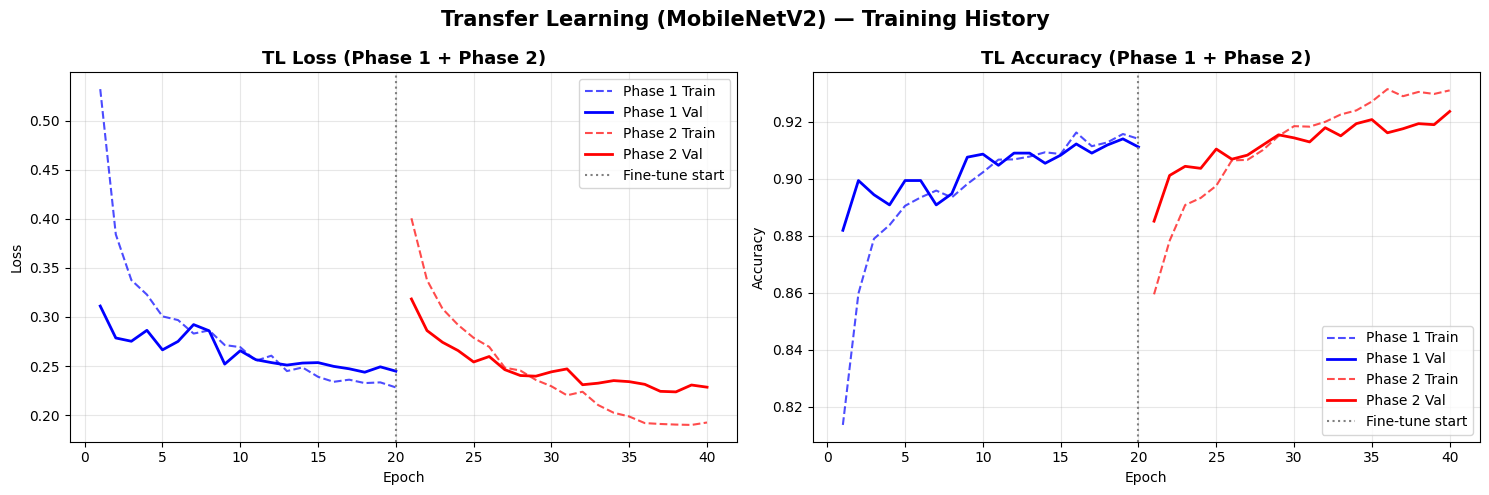

In [ ]:
# ── 7.5 Plot TL Training Curves (Both Phases) ─────────────────────────────────
def plot_tl_history(h1, h2, save_name='tl_history.png'):
    e1 = range(1, len(h1.history['loss']) + 1)
    e2 = range(len(e1) + 1, len(e1) + len(h2.history['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    for ax, metric, ylabel in zip(
        axes,
        [('loss','val_loss'), ('accuracy','val_accuracy')],
        ['Loss', 'Accuracy']
    ):
        ax.plot(e1, h1.history[metric[0]], 'b--', alpha=0.7, label='Phase 1 Train')
        ax.plot(e1, h1.history[metric[1]], 'b-',  linewidth=2, label='Phase 1 Val')
        ax.plot(e2, h2.history[metric[0]], 'r--', alpha=0.7, label='Phase 2 Train')
        ax.plot(e2, h2.history[metric[1]], 'r-',  linewidth=2, label='Phase 2 Val')
        ax.axvline(x=len(e1), color='gray', linestyle=':', label='Fine-tune start')
        ax.set_title(f'TL {ylabel} (Phase 1 + Phase 2)', fontsize=13, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.legend(); ax.grid(alpha=0.3)

    plt.suptitle('Transfer Learning (MobileNetV2) — Training History', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()

plot_tl_history(history_tl_phase1, history_tl_phase2)


  MobileNetV2 Transfer Learning — Evaluation Results
  Test Loss     : 0.1981
  Test Accuracy : 0.9240 (92.40%)

Classification Report:
              precision    recall  f1-score   support

   buildings       0.95      0.92      0.93       437
      forest       0.99      0.99      0.99       474
     glacier       0.89      0.85      0.87       553
    mountain       0.87      0.87      0.87       525
         sea       0.94      0.97      0.95       510
      street       0.92      0.96      0.94       501

    accuracy                           0.92      3000
   macro avg       0.93      0.93      0.93      3000
weighted avg       0.92      0.92      0.92      3000



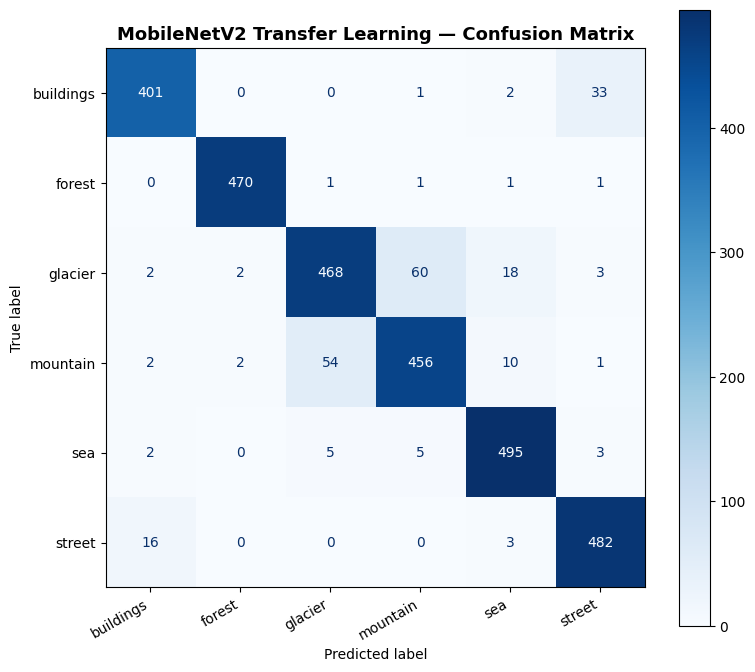

In [ ]:
# ── 7.6 Evaluate Transfer Learning Model ─────────────────────────────────────
# Fix - convert list to dict
CLASS_LABELS_DICT = {i: name for i, name in enumerate(CLASS_NAMES)}

tl_loss, tl_acc, tl_pred, tl_true = evaluate_model(
    tl_model, tl_test_gen, CLASS_LABELS_DICT, 'MobileNetV2 Transfer Learning'
)

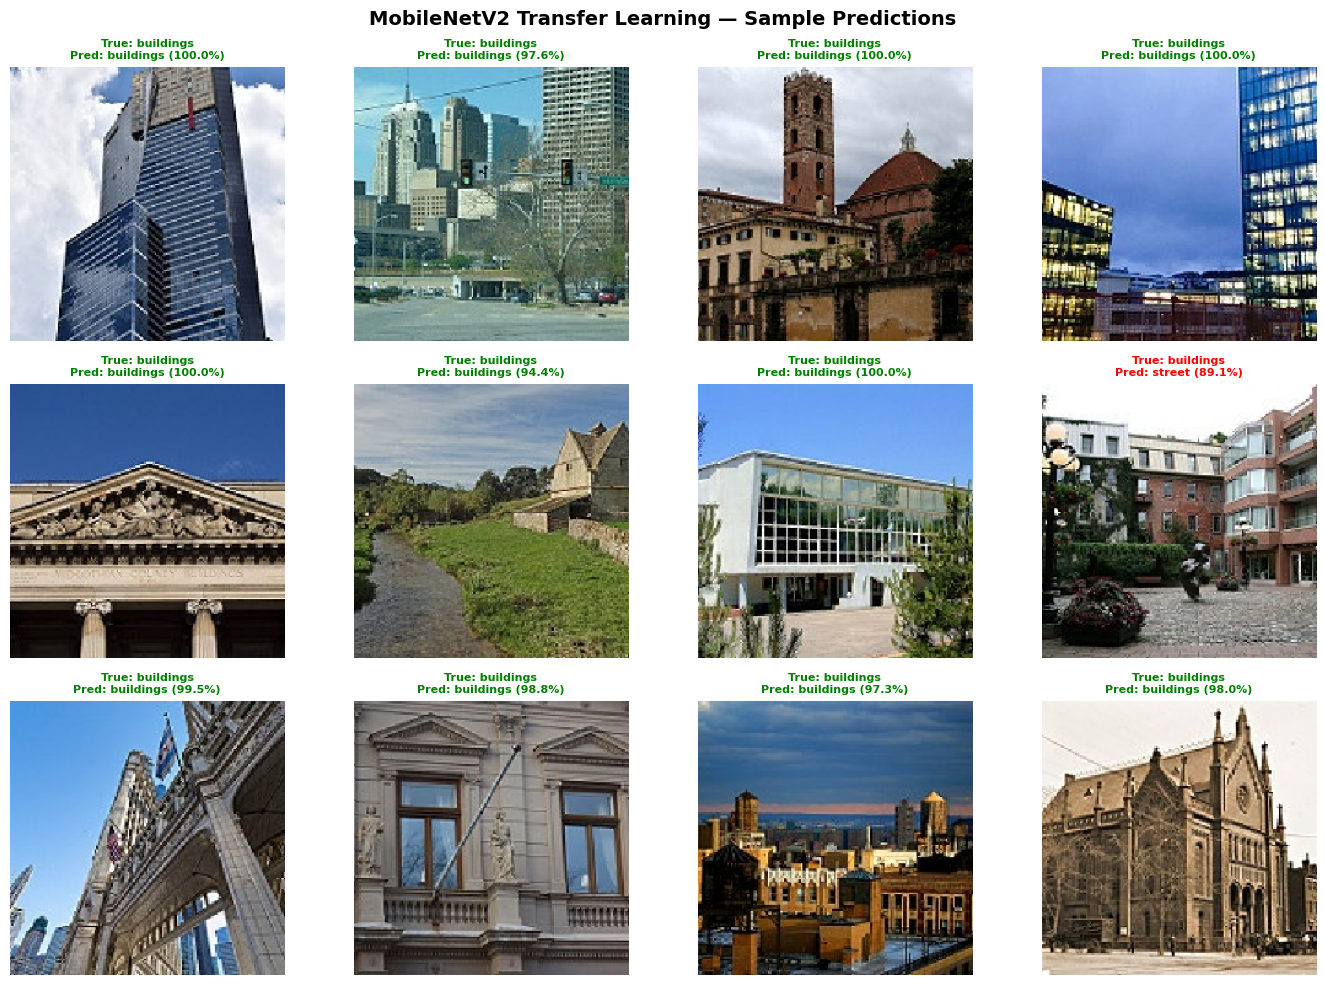

In [ ]:
# ── 7.7 Transfer Learning Predictions Visualization ──────────────────────────
tl_test_gen.reset()
tl_imgs, tl_labels = next(tl_test_gen)
tl_preds = tl_model.predict(tl_imgs, verbose=0)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('MobileNetV2 Transfer Learning — Sample Predictions', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    # Undo MobileNet preprocessing for display (approx)
    img_disp = (tl_imgs[i] + 1.0) / 2.0
    img_disp = np.clip(img_disp, 0, 1)
    ax.imshow(img_disp)
    true_label = CLASS_LABELS[np.argmax(tl_labels[i])]
    pred_label = CLASS_LABELS[np.argmax(tl_preds[i])]
    confidence = np.max(tl_preds[i]) * 100
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)',
                 fontsize=8, color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('tl_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Final Comprehensive Comparison


Model                            Test Acc (%)    Test Loss  Train Time (s)
---------------------------------------------------------------------------
Baseline CNN                            85.70       0.4284          1858.4
Deeper CNN (Adam)                       88.13       0.3524          3143.1
Deeper CNN (SGD)                        87.63       0.3736          3445.5
Ablation (No Dropout)                   88.97       0.3069             N/A
MobileNetV2 Transfer                    92.40       0.1981          6211.6


/tmp/ipykernel_57/318763694.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=20, ha='right', fontsize=9)


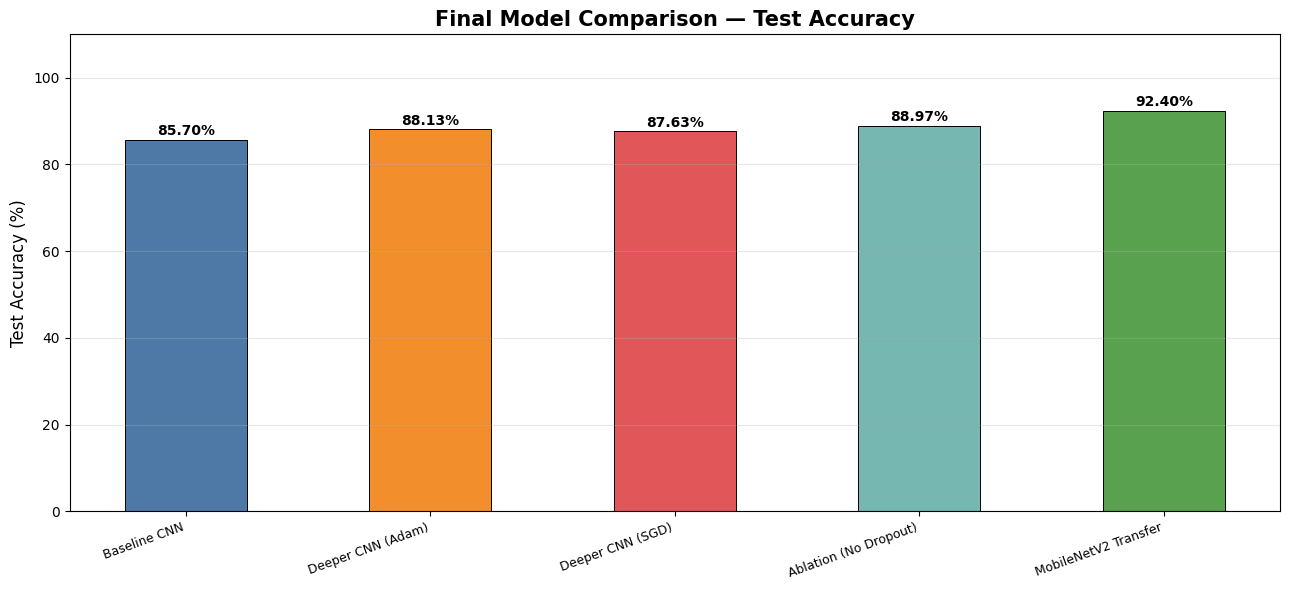

In [ ]:
# ── 8.1 All Models Summary ────────────────────────────────────────────────────
all_results = [
    ('Baseline CNN',              b_acc*100,  b_loss,  baseline_train_time),
    ('Deeper CNN (Adam)',         d_acc*100,  d_loss,  deeper_train_time_adam),
    ('Deeper CNN (SGD)',          sgd_acc*100,sgd_loss,deeper_train_time_sgd),
    ('Ablation (No Dropout)',     abl_acc*100,abl_loss, None),
    ('MobileNetV2 Transfer',      tl_acc*100, tl_loss, tl_total_time),
]

print("\n" + "="*75)
print(f"{'Model':<30} {'Test Acc (%)':>14} {'Test Loss':>12} {'Train Time (s)':>15}")
print("-"*75)
for name, acc, loss, t in all_results:
    t_str = f"{t:.1f}" if t else 'N/A'
    print(f"{name:<30} {acc:>14.2f} {loss:>12.4f} {t_str:>15}")
print("="*75)

# Bar chart
names = [r[0] for r in all_results]
accs  = [r[1] for r in all_results]
colors_all = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f']

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(names, accs, color=colors_all, edgecolor='black', linewidth=0.7, width=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Final Model Comparison — Test Accuracy', fontsize=15, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_ylim(0, 110)
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()